Seleccione el archivo CSV de MHUTEMP:


Saving bio_data_10mindata_ult26_250926.csv to bio_data_10mindata_ult26_250926.csv

Archivo cargado correctamente:
bio_data_10mindata_ult26_250926.csv

CSV STRUCTURE
Número de columnas definidas: 9
Columnas: ['_id', '__v', 'createdAt', 'datetime', 'doorStatus', 'dsTemperature', 'humidity', 'time_slot', 'username']

CSV LOADED
Total records recovered: 27778
Rows with trailing fields: 26778
Incomplete rows discarded: 0

NODE ULT26-001
Total node records: 27778
First timestamp: 2026-08-21 17:43:38+00:00
Last timestamp: 2036-02-07 08:20:00+00:00


GROUP 1 - EXTENDED FIELD MONITORING
Node:                         ULT26-001
Start:                        2026-08-21 19:07:00+00:00
End:                          2026-09-08 21:40:00+00:00
Duration:                     18.106 days
Duration:                     434.55 hours
----------------------------------------------------------------------
Total database records:       26,073
Valid temperature records:    26,071
Missing temperature records:  2
-

,datetime,interval_s,dsTemperature,doorStatus
25682,2026-09-08 15:10:16+00:00,136.0,-29.7,closed
6755,2026-08-26 11:42:55+00:00,114.0,-30.7,closed
25089,2026-09-08 05:16:48+00:00,108.0,-29.9,closed
17870,2026-09-03 04:57:46+00:00,106.0,-30.0,closed
26044,2026-09-08 21:12:39+00:00,98.0,-30.3,closed
5038,2026-08-25 07:05:32+00:00,92.0,-30.6,closed



DAILY RECORD COUNTS


,records
date,
2026-08-21,293
2026-08-22,1440
2026-08-23,1440
2026-08-24,1440
2026-08-25,1440
2026-08-26,1440
2026-08-27,1440
2026-08-28,1440
2026-08-29,1440


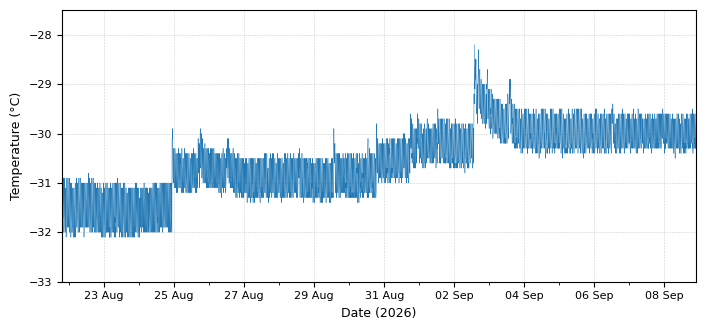


FILES GENERATED
Fig6_ULT26_001_Group1_18days.pdf
Fig6_ULT26_001_Group1_18days_600dpi.png
ULT26_001_Group1_clean.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# ============================================================
# HRFEST 2026 - PAPER 01
# FIGURE 6
#
# MHUTEMP - Plasma Freezer Monitoring
# Node: ULT26-001
#
# GROUP 1:
# 21-Aug-2026 19:07 UTC
# to
# 08-Sep-2026 21:40 UTC
#
# Database recording interval: approximately 1 minute
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from google.colab import files


# ============================================================
# 2. UPLOAD CSV
# ============================================================

print("Seleccione el archivo CSV de MHUTEMP:")

uploaded = files.upload()

filename = next(iter(uploaded))

print("\nArchivo cargado correctamente:")
print(filename)


# ============================================================
# 3. READ CSV
#
# IMPORTANT:
# The CSV header defines 9 columns.
#
# Some rows contain additional trailing fields.
# For this analysis we retain ONLY the first 9 fields,
# corresponding exactly to the columns defined by the header.
# ============================================================

rows = []

rows_with_extra_fields = 0
incomplete_rows = 0


with open(
    filename,
    "r",
    encoding="utf-8-sig",
    errors="replace",
    newline=""
) as f:

    reader = csv.reader(f)

    # Read CSV header
    header = next(reader)

    expected_fields = len(header)

    print("\n======================================")
    print("CSV STRUCTURE")
    print("======================================")

    print(
        "Número de columnas definidas:",
        expected_fields
    )

    print(
        "Columnas:",
        header
    )

    # --------------------------------------------------------
    # Read every CSV row
    # --------------------------------------------------------

    for line_number, row in enumerate(
        reader,
        start=2
    ):

        # ----------------------------------------------------
        # Valid row:
        # at least the 9 required fields exist
        # ----------------------------------------------------

        if len(row) >= expected_fields:

            # Keep ONLY the fields defined
            # by the CSV header
            valid_row = row[:expected_fields]

            rows.append(valid_row)

            # Count rows containing additional fields
            if len(row) > expected_fields:

                rows_with_extra_fields += 1

        # ----------------------------------------------------
        # Truly incomplete row
        # ----------------------------------------------------

        else:

            incomplete_rows += 1

            # Display only first 10
            if incomplete_rows <= 10:

                print(
                    "\nFila incompleta:",
                    line_number
                )

                print(row)


# ============================================================
# 4. CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(
    rows,
    columns=header
)


print("\n======================================")
print("CSV LOADED")
print("======================================")

print(
    "Total records recovered:",
    len(df)
)

print(
    "Rows with trailing fields:",
    rows_with_extra_fields
)

print(
    "Incomplete rows discarded:",
    incomplete_rows
)

print("======================================")


# ============================================================
# 5. CONVERT DATA TYPES
# ============================================================

# Datetime
df["datetime"] = pd.to_datetime(
    df["datetime"],
    errors="coerce",
    utc=True
)


# PT100 temperature
df["dsTemperature"] = pd.to_numeric(
    df["dsTemperature"],
    errors="coerce"
)


# ============================================================
# 6. FILTER NODE ULT26-001
# ============================================================

df_node = df[
    df["username"]
    .astype(str)
    .str.strip()
    == "ULT26-001"
].copy()


print("\n======================================")
print("NODE ULT26-001")
print("======================================")

print(
    "Total node records:",
    len(df_node)
)

print(
    "First timestamp:",
    df_node["datetime"].min()
)

print(
    "Last timestamp:",
    df_node["datetime"].max()
)

print("======================================")


# ============================================================
# 7. DEFINE GROUP 1
# ============================================================

start_date = pd.Timestamp(
    "2026-08-21 19:07:00",
    tz="UTC"
)

end_date = pd.Timestamp(
    "2026-09-08 21:40:00",
    tz="UTC"
)


# ============================================================
# 8. FILTER GROUP 1
# ============================================================

df_g1 = df_node[
    (df_node["datetime"] >= start_date)
    &
    (df_node["datetime"] <= end_date)
].copy()


# Sort chronologically
df_g1 = df_g1.sort_values(
    "datetime"
).reset_index(drop=True)


# ============================================================
# 9. REMOVE INVALID TEMPERATURE ONLY FOR TEMPERATURE ANALYSIS
# ============================================================

df_temp = df_g1.dropna(
    subset=[
        "datetime",
        "dsTemperature"
    ]
).copy()


# ============================================================
# 10. GROUP 1 BASIC INFORMATION
# ============================================================

N_total = len(df_g1)

N_temp = len(df_temp)

N_missing_temp = (
    N_total - N_temp
)


first_time = (
    df_g1["datetime"].min()
)

last_time = (
    df_g1["datetime"].max()
)


duration_seconds = (
    last_time - first_time
).total_seconds()


duration_hours = (
    duration_seconds / 3600
)

duration_days = (
    duration_seconds / 86400
)


# ============================================================
# 11. TEMPERATURE STATISTICS
# ============================================================

Tmin = (
    df_temp["dsTemperature"].min()
)

Tmax = (
    df_temp["dsTemperature"].max()
)

Tmean = (
    df_temp["dsTemperature"].mean()
)

Tmedian = (
    df_temp["dsTemperature"].median()
)

Tstd = (
    df_temp["dsTemperature"].std()
)

Q1 = (
    df_temp["dsTemperature"]
    .quantile(0.25)
)

Q3 = (
    df_temp["dsTemperature"]
    .quantile(0.75)
)


# ============================================================
# 12. INTER-RECORD INTERVAL
# ============================================================

df_g1["interval_s"] = (
    df_g1["datetime"]
    .diff()
    .dt.total_seconds()
)


intervals = (
    df_g1["interval_s"]
    .dropna()
)


median_interval = (
    intervals.median()
)

mean_interval = (
    intervals.mean()
)

p95_interval = (
    intervals.quantile(0.95)
)

p99_interval = (
    intervals.quantile(0.99)
)


# ============================================================
# 13. GAP ANALYSIS
# ============================================================

gaps_90 = (
    intervals > 90
).sum()

gaps_120 = (
    intervals > 120
).sum()

gaps_180 = (
    intervals > 180
).sum()

gaps_300 = (
    intervals > 300
).sum()


max_gap = (
    intervals.max()
)


percent_90 = (
    (intervals <= 90).mean()
    * 100
)


# ============================================================
# 14. DOOR STATUS
# ============================================================

if "doorStatus" in df_g1.columns:

    door_open = (
        df_g1["doorStatus"]
        .astype(str)
        .str.lower()
        .str.strip()
        .eq("open")
        .sum()
    )

else:

    door_open = np.nan


# ============================================================
# 15. PRINT FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("GROUP 1 - EXTENDED FIELD MONITORING")
print("=" * 70)

print(
    f"Node:                         "
    f"ULT26-001"
)

print(
    f"Start:                        "
    f"{first_time}"
)

print(
    f"End:                          "
    f"{last_time}"
)

print(
    f"Duration:                     "
    f"{duration_days:.3f} days"
)

print(
    f"Duration:                     "
    f"{duration_hours:.2f} hours"
)

print("-" * 70)

print(
    f"Total database records:       "
    f"{N_total:,}"
)

print(
    f"Valid temperature records:    "
    f"{N_temp:,}"
)

print(
    f"Missing temperature records:  "
    f"{N_missing_temp:,}"
)

print("-" * 70)

print(
    f"Minimum temperature:          "
    f"{Tmin:.2f} °C"
)

print(
    f"Maximum temperature:          "
    f"{Tmax:.2f} °C"
)

print(
    f"Mean temperature:             "
    f"{Tmean:.3f} °C"
)

print(
    f"Median temperature:           "
    f"{Tmedian:.2f} °C"
)

print(
    f"Standard deviation:           "
    f"{Tstd:.3f} °C"
)

print(
    f"Q1:                           "
    f"{Q1:.2f} °C"
)

print(
    f"Q3:                           "
    f"{Q3:.2f} °C"
)

print("-" * 70)

print(
    f"Mean inter-record interval:   "
    f"{mean_interval:.3f} s"
)

print(
    f"Median inter-record interval: "
    f"{median_interval:.3f} s"
)

print(
    f"95th percentile interval:     "
    f"{p95_interval:.3f} s"
)

print(
    f"99th percentile interval:     "
    f"{p99_interval:.3f} s"
)

print("-" * 70)

print(
    f"Intervals > 90 s:             "
    f"{gaps_90}"
)

print(
    f"Intervals > 120 s:            "
    f"{gaps_120}"
)

print(
    f"Intervals > 180 s:            "
    f"{gaps_180}"
)

print(
    f"Intervals > 300 s:            "
    f"{gaps_300}"
)

print(
    f"Maximum gap:                  "
    f"{max_gap:.3f} s"
)

print(
    f"Intervals <= 90 s:            "
    f"{percent_90:.3f} %"
)

print("-" * 70)

print(
    f"Door-open records:            "
    f"{door_open}"
)

print("=" * 70)


# ============================================================
# 16. DISPLAY LARGEST GAPS
# ============================================================

largest_gaps = (
    df_g1[
        df_g1["interval_s"] > 90
    ][
        [
            "datetime",
            "interval_s",
            "dsTemperature",
            "doorStatus"
        ]
    ]
    .sort_values(
        "interval_s",
        ascending=False
    )
)


print("\n======================================")
print("INTER-RECORD GAPS > 90 s")
print("======================================")

if len(largest_gaps) == 0:

    print(
        "No intervals > 90 s detected."
    )

else:

    display(largest_gaps)


# ============================================================
# 17. DAILY RECORD COUNTS
# ============================================================

df_g1["date"] = (
    df_g1["datetime"]
    .dt.date
)


daily_counts = (
    df_g1
    .groupby("date")
    .size()
)


print("\n======================================")
print("DAILY RECORD COUNTS")
print("======================================")

display(
    daily_counts.to_frame(
        name="records"
    )
)


# ============================================================
# 18. FIGURE 6
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.16, 3.4)
)


# Original PT100 measurements
ax.plot(
    df_temp["datetime"],
    df_temp["dsTemperature"],
    linewidth=0.35
)


# ============================================================
# 19. FIGURE AXES
# ============================================================

ax.set_xlabel(
    "Date (2026)",
    fontsize=9
)

ax.set_ylabel(
    "Temperature (°C)",
    fontsize=9
)


# ============================================================
# 20. X AXIS
# ============================================================

# Major tick every 2 days
ax.xaxis.set_major_locator(
    mdates.DayLocator(
        interval=2
    )
)


# Format:
# 21 Aug, 23 Aug, ...
ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b"
    )
)


# Minor tick every day
ax.xaxis.set_minor_locator(
    mdates.DayLocator(
        interval=1
    )
)


# ============================================================
# 21. AXIS LIMITS
# ============================================================

ax.set_xlim(
    start_date,
    end_date
)


# Based on observed operating range
# with visual margin
ax.set_ylim(
    -33,
    -27.5
)


# ============================================================
# 22. GRID
# ============================================================

ax.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.4,
    alpha=0.6
)


# ============================================================
# 23. IEEE-LIKE FORMATTING
# ============================================================

ax.tick_params(
    axis="both",
    which="major",
    labelsize=8
)


ax.tick_params(
    axis="both",
    which="minor",
    length=2
)


plt.tight_layout()


# ============================================================
# 24. SAVE FIGURE
# ============================================================

pdf_name = (
    "Fig6_ULT26_001_Group1_18days.pdf"
)

png_name = (
    "Fig6_ULT26_001_Group1_18days_600dpi.png"
)


plt.savefig(
    pdf_name,
    bbox_inches="tight"
)


plt.savefig(
    png_name,
    dpi=600,
    bbox_inches="tight"
)


# Show figure
plt.show()


# ============================================================
# 25. SAVE CLEAN GROUP 1 CSV
# ============================================================

clean_csv_name = (
    "ULT26_001_Group1_clean.csv"
)


df_g1.to_csv(
    clean_csv_name,
    index=False
)


# ============================================================
# 26. FINAL INFORMATION
# ============================================================

print("\n======================================")
print("FILES GENERATED")
print("======================================")

print(pdf_name)
print(png_name)
print(clean_csv_name)

print("======================================")


# ============================================================
# 27. DOWNLOAD FILES
# ============================================================

files.download(
    pdf_name
)

files.download(
    png_name
)

files.download(
    clean_csv_name
)